# Benchmark Rata-rata Waktu Inferensi End-to-End — Kelayakan Produksi

Notebook ini **terpisah** dari notebook training utama (`log-anomaly-bgl-2.ipynb`) dan berfokus khusus
untuk mengukur **rata-rata waktu inferensi end-to-end** pipeline deteksi anomali log pada dataset **BGL**,
dengan **sliding window berukuran 20 baris log** per sekuens:

```
Raw log lines (20 baris/window) -> Drain3 Parsing -> Gabung Template
                                 -> DistilBERT Embedding (Mean Pooling)
                                 -> StandardScaler -> VAE Forward (Reconstruction Error)
                                 -> (opsional) Threshold Decision
```

**Perbedaan dengan versi sebelumnya:** sebelumnya tahap Drain3 parsing diukur **terpisah** dari tahap
embedding + VAE (dan tahap embedding memakai teks sintetis/placeholder jika variabel `windows` dari sesi
training tidak tersedia). Pada notebook ini, seluruh tahap **digabung menjadi satu pipeline yang benar-benar
dijalankan berurutan** di atas baris log mentah asli dari dataset BGL, lalu **waktu totalnya diukur per
window** — sehingga angka rata-rata yang dilaporkan benar-benar merepresentasikan latency produksi
end-to-end, bukan estimasi per-komponen yang dijumlahkan secara terpisah.

Tujuan: menilai apakah pipeline **layak dipakai untuk keperluan produksi** (mis. real-time/near-real-time
monitoring log) dengan mengukur:

1. **Rata-rata waktu inferensi end-to-end per window** (mean, median, p90, p95, p99, max) — window = 20
   baris log mentah yang diparsing dengan Drain3, dibentuk embedding-nya, lalu dihitung reconstruction
   error-nya oleh VAE.
2. **Kontribusi tiap tahap** (Drain3 parsing, DistilBERT embedding, Scaling+VAE) terhadap total latency.
3. **Throughput** (window/detik) dan **verdict kelayakan produksi** dibandingkan target SLA.

> **Prasyarat / Asumsi:**
> - Model VAE (`vae_best.pt`) dan **threshold** hasil training **diasumsikan sudah didapat** dari proses
>   pelatihan pada notebook training utama — notebook ini **tidak melakukan training ulang**, hanya memuat
>   dan menggunakannya untuk inferensi.
> - Artefak yang dibutuhkan: `embeddings_bgl.npy`, `labels_bgl.npy` (untuk merekonstruksi `StandardScaler`),
>   `best_model/vae_best.pt` (bobot VAE terlatih), nilai/`threshold_bgl.npy` (threshold hasil training), dan
>   file log mentah asli `BGL.log` (**wajib**, karena tahap Drain3 parsing sekarang diukur sebagai bagian
>   integral dari pipeline end-to-end, bukan lagi opsional).


## 1. Instalasi Dependensi & Import

In [1]:
%pip install -q drain3 -U transformers

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 32.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyiceberg 0.11.1 requires cachetools<7.0,>=5.5, but you have cachetools 4.2.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, time, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import DistilBertTokenizer, DistilBertModel
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


## 2. Konfigurasi

Sesuaikan path di bawah agar mengarah ke artefak yang dihasilkan notebook training utama.

- `window_size` : jumlah baris log mentah yang digabung menjadi satu sekuens/sampel (sliding window),
  **20** sesuai skema yang dipakai pada dataset BGL.
- `threshold` / `threshold_path` : nilai threshold hasil training. **Diasumsikan sudah didapat** dari
  proses pelatihan — isi salah satu (nilai langsung atau path file `.npy` berisi skalar).
- `raw_log_file` : **wajib** diisi, karena tahap Drain3 parsing sekarang menjadi bagian dari pengukuran
  end-to-end (bukan lagi diukur terpisah/opsional seperti versi sebelumnya).
- `sla_targets_ms` : daftar target SLA (ms per window) yang dipakai sebagai acuan penilaian kelayakan
  produksi — silakan sesuaikan dengan kebutuhan use-case.

In [3]:
IS_KAGGLE = os.path.exists("/kaggle/input")
BASE_INPUT_DIR = "/kaggle/input/datasets/shutterisland/log-system-detection-anomaly" if IS_KAGGLE else "./outputs"

BENCH_CONFIG = {
    # Artefak dari notebook training utama
    "output_dir"       : "/kaggle/working/",
    "embeddings_path"  : os.path.join(BASE_INPUT_DIR, "embeddings_bgl.npy"),
    "labels_path"      : os.path.join(BASE_INPUT_DIR, "labels_bgl.npy"),
    "vae_weights_path" : os.path.join(BASE_INPUT_DIR, "vae_best.pt"),

    # Threshold hasil training (nilai reconstruction error yang memisahkan normal/anomali).
    # DIASUMSIKAN SUDAH DIDAPAT dari notebook training utama. Isi salah satu:
    "threshold_path" : os.path.join(BASE_INPUT_DIR, "threshold_bgl.npy"),  # file .npy berisi skalar
    "threshold"      : None,   # atau isi manual mis. 0.0123 jika threshold_path tidak tersedia

    # Arsitektur VAE — HARUS SAMA dengan yang dipakai saat training final
    "hidden_dims" : [512, 256, 128],
    "latent_dim"  : 64,          # ganti sesuai best_params hasil Optuna di notebook utama
    "input_dim"   : 768,         # dimensi output DistilBERT

    # Embedder
    "bert_model"      : "distilbert-base-uncased",
    "bert_max_length" : 512,

    # File log mentah BGL — WAJIB tersedia untuk mengukur pipeline end-to-end penuh
    # (Drain3 parsing -> windowing -> embedding -> VAE).
    "raw_log_file"   : "/kaggle/input/datasets/shutterisland/log-system-detection-anomaly/BGL.log",

    # Konfigurasi Drain3 (harus konsisten dengan yang dipakai saat training)
    "drain_sim_th"               : 0.4,
    "drain_depth"                : 4,
    "drain_max_children"         : 100,
    "parametrize_numeric_tokens" : True,

    # Sliding window: jumlah baris log mentah yang digabung menjadi satu sekuens/sampel
    "window_size" : 20,

    # Skenario benchmark end-to-end (batch=1 -> latency produksi single-request per window)
    "n_bench_samples"       : 10000,   # jumlah window yang diukur
    "n_warmup_lines_drain3" : 2000,   # baris log dipakai utk stabilisasi cluster Drain3 sebelum diukur
    "n_repeat"              : 5,      # ulangi pengukuran seluruh window utk stabilitas statistik

    # Batch sizes untuk analisis sensitivitas tambahan (opsional, dari embedding tersimpan, Bagian 8)
    "batch_sizes" : [1, 8, 16, 32, 64, 128, 256],
    "n_warmup"    : 5,

    # Target SLA (ms per window) — sesuaikan dengan kebutuhan produksi
    "sla_targets_ms": {
        "real_time (< 100 ms)"      : 100,
        "near_real_time (< 500 ms)" : 500,
        "batch_1s (< 1000 ms)"      : 1000,
    },

    "seed": 42,
}

os.makedirs(BENCH_CONFIG["output_dir"], exist_ok=True)
torch.manual_seed(BENCH_CONFIG["seed"])
np.random.seed(BENCH_CONFIG["seed"])

for k in ["embeddings_path", "labels_path", "vae_weights_path", "raw_log_file"]:
    p = BENCH_CONFIG[k]
    status = "OK" if os.path.exists(p) else "TIDAK DITEMUKAN"
    print(f"  [{status}] {k}: {p}")

  [OK] embeddings_path: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/embeddings_bgl.npy
  [OK] labels_path: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/labels_bgl.npy
  [OK] vae_weights_path: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/vae_best.pt
  [OK] raw_log_file: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/BGL.log


## 3. Muat Artefak (Embeddings, Scaler, Model VAE, Threshold)

`StandardScaler` tidak disimpan eksplisit oleh notebook training utama, sehingga di sini kita
**merekonstruksinya** dengan fitting ulang pada embedding berlabel normal — persis skema yang
dipakai saat training. Threshold **dimuat** (bukan dihitung ulang) karena diasumsikan sudah
merupakan hasil dari proses pelatihan.

In [4]:
assert os.path.exists(BENCH_CONFIG["embeddings_path"]), (
    "embeddings.npy tidak ditemukan. Jalankan dahulu notebook training utama "
    "sampai bagian embedding agar file ini tersimpan."
)
assert os.path.exists(BENCH_CONFIG["vae_weights_path"]), (
    "vae_best.pt tidak ditemukan. Jalankan dahulu notebook training utama "
    "sampai selesai training VAE final."
)
assert BENCH_CONFIG["raw_log_file"] and os.path.exists(BENCH_CONFIG["raw_log_file"]), (
    "raw_log_file tidak ditemukan. File log mentah BGL WAJIB tersedia untuk mengukur "
    "pipeline end-to-end penuh (Drain3 parsing -> windowing -> embedding -> VAE)."
)

embeddings = np.load(BENCH_CONFIG["embeddings_path"])
labels     = np.load(BENCH_CONFIG["labels_path"])
print(f"Embeddings: {embeddings.shape}, Labels: {labels.shape}")

valid_mask = labels != -1
known_emb, known_lbl = embeddings[valid_mask], labels[valid_mask]
normal_emb = known_emb[known_lbl == 0]

# Rekonstruksi scaler: fit pada seluruh data normal (mendekati kondisi training)
scaler = StandardScaler()
scaler.fit(normal_emb)
print(f"Scaler direkonstruksi dari {len(normal_emb):,} sampel normal.")

# Muat threshold hasil training (DIASUMSIKAN SUDAH DIDAPAT dari proses pelatihan)
THRESHOLD = BENCH_CONFIG["threshold"]
if THRESHOLD is None and os.path.exists(BENCH_CONFIG["threshold_path"]):
    THRESHOLD = float(np.load(BENCH_CONFIG["threshold_path"]))
if THRESHOLD is not None:
    print(f"Threshold dimuat: {THRESHOLD:.6f}")
else:
    print("[PERINGATAN] Threshold belum tersedia (threshold_path tidak ditemukan & "
          "BENCH_CONFIG['threshold'] masih None). Reconstruction error tetap akan dihitung "
          "dan latency tetap diukur, hanya keputusan normal/anomali yang dilewati. "
          "Isi BENCH_CONFIG['threshold'] atau ['threshold_path'] dengan nilai hasil training "
          "untuk mengaktifkan keputusan threshold.")

# Kumpulan embedding tersimpan, dipakai untuk analisis sensitivitas batch size opsional (Bagian 8)
bench_pool_emb = known_emb
bench_pool_lbl = known_lbl
n_bench_emb = min(BENCH_CONFIG["n_bench_samples"], len(bench_pool_emb))
rng = np.random.default_rng(BENCH_CONFIG["seed"])
bench_idx = rng.choice(len(bench_pool_emb), size=n_bench_emb, replace=False)
bench_emb_raw = bench_pool_emb[bench_idx]
bench_lbl     = bench_pool_lbl[bench_idx]
print(f"Sampel embedding utk analisis batch-size (Bagian 8): {n_bench_emb:,} "
      f"(Normal={(bench_lbl==0).sum():,}, Anomali={(bench_lbl==1).sum():,})")

Embeddings: (235674, 768), Labels: (235674,)
Scaler direkonstruksi dari 215,418 sampel normal.
[PERINGATAN] Threshold belum tersedia (threshold_path tidak ditemukan & BENCH_CONFIG['threshold'] masih None). Reconstruction error tetap akan dihitung dan latency tetap diukur, hanya keputusan normal/anomali yang dilewati. Isi BENCH_CONFIG['threshold'] atau ['threshold_path'] dengan nilai hasil training untuk mengaktifkan keputusan threshold.
Sampel embedding utk analisis batch-size (Bagian 8): 10,000 (Normal=9,180, Anomali=820)


## 4. Muat Model VAE (Diasumsikan Sudah Dilatih)

In [5]:
class VAEEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.LeakyReLU()]
            prev = h
        self.net = nn.Sequential(*layers)
        self.mu, self.logvar = nn.Linear(prev, latent_dim), nn.Linear(prev, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        layers, prev = [], latent_dim
        for h in reversed(hidden_dims):
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.LeakyReLU()]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        self.encoder = VAEEncoder(input_dim, hidden_dims, latent_dim)
        self.decoder = VAEDecoder(latent_dim, hidden_dims, input_dim)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + torch.randn_like(std) * std
        return mu

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def reconstruction_loss(self, x):
        self.eval()
        with torch.no_grad():
            recon, _, _ = self.forward(x)
            loss = F.mse_loss(recon, x, reduction="none").mean(dim=1)
        return loss.cpu().numpy()


vae = VAE(BENCH_CONFIG["input_dim"], BENCH_CONFIG["hidden_dims"], BENCH_CONFIG["latent_dim"]).to(DEVICE)
state_dict = torch.load(BENCH_CONFIG["vae_weights_path"], map_location=DEVICE)
vae.load_state_dict(state_dict)
vae.eval()
n_params = sum(p.numel() for p in vae.parameters())
print(f"VAE dimuat dari: {BENCH_CONFIG['vae_weights_path']}")
print(f"Jumlah parameter VAE: {n_params:,}")

VAE dimuat dari: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/vae_best.pt
Jumlah parameter VAE: 1,144,960


In [6]:
embedder_tokenizer = DistilBertTokenizer.from_pretrained(BENCH_CONFIG["bert_model"])
embedder_model     = DistilBertModel.from_pretrained(BENCH_CONFIG["bert_model"]).to(DEVICE)
embedder_model.eval()
n_bert_params = sum(p.numel() for p in embedder_model.parameters())
print(f"DistilBERT dimuat: {BENCH_CONFIG['bert_model']}")
print(f"Jumlah parameter DistilBERT: {n_bert_params:,}")
print(f"Total parameter pipeline (BERT + VAE): {n_bert_params + n_params:,}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT dimuat: distilbert-base-uncased
Jumlah parameter DistilBERT: 66,362,880
Total parameter pipeline (BERT + VAE): 67,507,840


## 5. Muat Drain3 Template Miner & Bentuk Sliding Window dari Log Mentah

Baris log mentah dibaca dari `raw_log_file`, lalu dibagi menjadi dua bagian:
- **`warmup_lines`** — dipakai untuk menstabilkan cluster template Drain3 sebelum pengukuran dimulai
  (meniru kondisi produksi di mana miner sudah berjalan lama), **tidak ikut diukur waktunya**.
- **`measure_lines`** — dipecah menjadi window **non-overlapping** berukuran `window_size` (20 baris)
  yang benar-benar dipakai untuk mengukur latency end-to-end.

In [7]:
drain_config = TemplateMinerConfig()
drain_config.drain_sim_th = BENCH_CONFIG["drain_sim_th"]
drain_config.drain_depth = BENCH_CONFIG["drain_depth"]
drain_config.drain_max_children = BENCH_CONFIG["drain_max_children"]
drain_config.parametrize_numeric_tokens = BENCH_CONFIG["parametrize_numeric_tokens"]
drain_miner = TemplateMiner(config=drain_config)

WINDOW_SIZE = BENCH_CONFIG["window_size"]
n_warmup_lines = BENCH_CONFIG["n_warmup_lines_drain3"]
n_lines_needed = n_warmup_lines + BENCH_CONFIG["n_bench_samples"] * WINDOW_SIZE

with open(BENCH_CONFIG["raw_log_file"], "r", encoding="utf-8", errors="replace") as f:
    raw_lines_all = [line.rstrip("\n") for _, line in zip(range(n_lines_needed), f)]

warmup_lines  = raw_lines_all[:n_warmup_lines]
measure_lines = raw_lines_all[n_warmup_lines:]


def build_sliding_windows(lines, window_size):
    """Bentuk daftar window (non-overlapping) berisi `window_size` baris log mentah."""
    n_windows = len(lines) // window_size
    return [lines[i * window_size:(i + 1) * window_size] for i in range(n_windows)]


bench_windows = build_sliding_windows(measure_lines, WINDOW_SIZE)

print(f"Total baris log dimuat        : {len(raw_lines_all):,}")
print(f"Baris untuk warmup Drain3     : {len(warmup_lines):,}")
print(f"Baris untuk pengukuran        : {len(measure_lines):,}")
print(f"Jumlah window (size={WINDOW_SIZE}) diukur : {len(bench_windows):,}")

Total baris log dimuat        : 202,000
Baris untuk warmup Drain3     : 2,000
Baris untuk pengukuran        : 200,000
Jumlah window (size=20) diukur : 10,000


## 6. Fungsi Pipeline Inferensi End-to-End Penuh

`run_full_pipeline_once` menjalankan **satu window** (20 baris log) melalui **seluruh pipeline secara
berurutan** — Drain3 parsing per baris -> gabung template -> DistilBERT embedding (mean pooling) ->
StandardScaler -> VAE forward -> reconstruction error -> (opsional) keputusan threshold — sambil mencatat
waktu tiap tahap, sehingga latency total maupun rinciannya bisa dianalisis.

In [8]:
@torch.no_grad()
def embed_texts(texts, tokenizer, model, max_length, device):
    enc = tokenizer(texts, padding=True, truncation=True,
                     max_length=max_length, return_tensors="pt").to(device)
    out = model(**enc)
    mask = enc["attention_mask"].unsqueeze(-1).float()
    summed = (out.last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return (summed / counts).cpu().numpy()


def predict_from_embeddings(emb_raw, scaler, vae, device, threshold=None):
    """Tahap: scaling -> VAE forward -> (opsional) thresholding. Dipakai terpisah bila
    embedding sudah tersedia (dipakai untuk analisis sensitivitas batch size di Bagian 8)."""
    emb_scaled = scaler.transform(emb_raw)
    x = torch.tensor(emb_scaled, dtype=torch.float32).to(device)
    losses = vae.reconstruction_loss(x)
    preds = (losses > threshold).astype(int) if threshold is not None else None
    return losses, preds


@torch.no_grad()
def run_full_pipeline_once(window_lines, miner, tokenizer, bert_model, scaler, vae, device,
                            max_length, threshold=None):
    """Pipeline END-TO-END PENUH untuk SATU window/sekuens (window_size baris log mentah):
    Drain3 parsing -> gabung template -> DistilBERT embedding -> StandardScaler -> VAE forward
    -> reconstruction error -> (opsional) keputusan threshold.
    Mengembalikan (reconstruction_error, prediksi, breakdown_waktu_ms)."""
    # 1) Parsing sekuens dengan Drain3
    t0 = time.perf_counter()
    templates = []
    for line in window_lines:
        result = miner.add_log_message(line)
        templates.append(result["template_mined"] if result else line)
    window_text = " [SEP] ".join(templates)
    t1 = time.perf_counter()

    # 2) Pembentukan embedding (DistilBERT, mean pooling)
    emb_raw = embed_texts([window_text], tokenizer, bert_model, max_length, device)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t2 = time.perf_counter()

    # 3) Scaling + VAE forward -> reconstruction error
    emb_scaled = scaler.transform(emb_raw)
    x = torch.tensor(emb_scaled, dtype=torch.float32).to(device)
    loss = float(vae.reconstruction_loss(x)[0])
    if device.type == "cuda":
        torch.cuda.synchronize()
    t3 = time.perf_counter()

    pred = int(loss > threshold) if threshold is not None else None
    breakdown_ms = {
        "drain3_ms"      : (t1 - t0) * 1000.0,
        "embedding_ms"   : (t2 - t1) * 1000.0,
        "scaling_vae_ms" : (t3 - t2) * 1000.0,
        "total_ms"       : (t3 - t0) * 1000.0,
    }
    return loss, pred, breakdown_ms


print("Fungsi pipeline end-to-end siap.")

Fungsi pipeline end-to-end siap.


## 7. Warmup

Dua jenis warmup dilakukan secara terpisah agar tidak saling mengganggu:
- Warmup **CUDA kernel** DistilBERT & VAE memakai teks dummy (bukan baris log asli).
- Warmup **cluster template Drain3** memakai `warmup_lines` (bukan bagian dari window yang diukur).

In [9]:
# Warmup CUDA kernel / graph BERT & VAE
dummy_text = "generic kernel event component reported a routine status message " * 3
_ = embed_texts([dummy_text], embedder_tokenizer, embedder_model,
                BENCH_CONFIG["bert_max_length"], DEVICE)
_dummy_scaled = scaler.transform(np.zeros((1, BENCH_CONFIG["input_dim"]), dtype=np.float32))
_ = vae.reconstruction_loss(torch.tensor(_dummy_scaled, dtype=torch.float32).to(DEVICE))
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

# Warmup Drain3: stabilkan cluster template dengan baris log terpisah (bukan bagian dari
# window yang akan diukur), meniru kondisi produksi di mana miner sudah berjalan lama.
for line in warmup_lines:
    drain_miner.add_log_message(line)

n_clusters = len(drain_miner.drain.clusters)
print(f"Warmup selesai. Drain3 miner memiliki {n_clusters:,} cluster template "
      f"setelah memproses {len(warmup_lines):,} baris log.")

Warmup selesai. Drain3 miner memiliki 2 cluster template setelah memproses 2,000 baris log.


## 8. Benchmark Rata-rata Waktu Inferensi End-to-End (Sliding Window = 20)

Ini adalah pengukuran utama notebook: setiap window (20 baris log) dijalankan melalui
`run_full_pipeline_once` secara **end-to-end penuh** (Drain3 -> embedding -> scaling -> VAE), waktunya
dicatat, lalu dirata-ratakan pada `BENCH_CONFIG["n_bench_samples"]` window (diulang
`BENCH_CONFIG["n_repeat"]` kali untuk stabilitas statistik).

In [10]:
records = []
for rep in range(BENCH_CONFIG["n_repeat"]):
    for window_lines in tqdm(bench_windows, desc=f"Repeat {rep + 1}/{BENCH_CONFIG['n_repeat']}"):
        loss, pred, bd = run_full_pipeline_once(
            window_lines, drain_miner, embedder_tokenizer, embedder_model,
            scaler, vae, DEVICE, BENCH_CONFIG["bert_max_length"], threshold=THRESHOLD
        )
        bd["repeat"] = rep
        bd["reconstruction_error"] = loss
        bd["prediction"] = pred
        records.append(bd)

e2e_full_df = pd.DataFrame(records)
print(f"Total pengukuran: {len(e2e_full_df):,} "
      f"(window_size={WINDOW_SIZE}, n_windows={len(bench_windows):,}, "
      f"n_repeat={BENCH_CONFIG['n_repeat']})")


def summarize_latency(values_ms):
    values_ms = np.asarray(values_ms, dtype=float)
    return {
        "n_samples": int(len(values_ms)),
        "mean_ms": float(np.mean(values_ms)),
        "median_ms": float(np.median(values_ms)),
        "p90_ms": float(np.percentile(values_ms, 90)),
        "p95_ms": float(np.percentile(values_ms, 95)),
        "p99_ms": float(np.percentile(values_ms, 99)),
        "max_ms": float(np.max(values_ms)),
        "throughput_window_per_s": float(1000.0 / np.mean(values_ms)),
    }


e2e_summary    = summarize_latency(e2e_full_df["total_ms"])
drain3_summary = summarize_latency(e2e_full_df["drain3_ms"])
embed_summary  = summarize_latency(e2e_full_df["embedding_ms"])
vae_summary    = summarize_latency(e2e_full_df["scaling_vae_ms"])

print("\n" + "=" * 70)
print(f" RATA-RATA WAKTU INFERENSI END-TO-END — Dataset BGL, sliding window = {WINDOW_SIZE}")
print("=" * 70)
print(f"  Jumlah sampel (window) diukur : {e2e_summary['n_samples']:,}")
print(f"  Rata-rata (mean)               : {e2e_summary['mean_ms']:.4f} ms/window")
print(f"  Median                          : {e2e_summary['median_ms']:.4f} ms/window")
print(f"  p90 / p95 / p99                : {e2e_summary['p90_ms']:.4f} / "
      f"{e2e_summary['p95_ms']:.4f} / {e2e_summary['p99_ms']:.4f} ms")
print(f"  Maksimum                        : {e2e_summary['max_ms']:.4f} ms")
print(f"  Throughput                      : {e2e_summary['throughput_window_per_s']:.2f} window/detik")
print(f"\n  -> setara {e2e_summary['mean_ms'] / WINDOW_SIZE:.4f} ms per baris log mentah "
      f"(dengan {WINDOW_SIZE} baris/window).")

print("\nRincian rata-rata per tahap pipeline:")
print(f"  1) Drain3 parsing ({WINDOW_SIZE} baris) : {drain3_summary['mean_ms']:.4f} ms "
      f"({drain3_summary['mean_ms'] / e2e_summary['mean_ms'] * 100:.1f}% dari total)")
print(f"  2) DistilBERT embedding          : {embed_summary['mean_ms']:.4f} ms "
      f"({embed_summary['mean_ms'] / e2e_summary['mean_ms'] * 100:.1f}% dari total)")
print(f"  3) Scaling + VAE forward         : {vae_summary['mean_ms']:.4f} ms "
      f"({vae_summary['mean_ms'] / e2e_summary['mean_ms'] * 100:.1f}% dari total)")

e2e_full_df.head()

Repeat 1/5:   0%|          | 0/10000 [00:00<?, ?it/s]

Repeat 2/5:   0%|          | 0/10000 [00:00<?, ?it/s]

Repeat 3/5:   0%|          | 0/10000 [00:00<?, ?it/s]

Repeat 4/5:   0%|          | 0/10000 [00:00<?, ?it/s]

Repeat 5/5:   0%|          | 0/10000 [00:00<?, ?it/s]

Total pengukuran: 50,000 (window_size=20, n_windows=10,000, n_repeat=5)

 RATA-RATA WAKTU INFERENSI END-TO-END — Dataset BGL, sliding window = 20
  Jumlah sampel (window) diukur : 50,000
  Rata-rata (mean)               : 19.9332 ms/window
  Median                          : 19.9819 ms/window
  p90 / p95 / p99                : 20.7174 / 20.9965 / 21.5422 ms
  Maksimum                        : 31.3766 ms
  Throughput                      : 50.17 window/detik

  -> setara 0.9967 ms per baris log mentah (dengan 20 baris/window).

Rincian rata-rata per tahap pipeline:
  1) Drain3 parsing (20 baris) : 0.2091 ms (1.0% dari total)
  2) DistilBERT embedding          : 18.3159 ms (91.9% dari total)
  3) Scaling + VAE forward         : 1.4083 ms (7.1% dari total)


,drain3_ms,embedding_ms,scaling_vae_ms,total_ms,repeat,reconstruction_error,prediction
0,0.254966,29.454210,1.667394,31.376570,0,1.03121,None
1,0.146491,26.580243,1.480071,28.206805,0,1.03121,None
2,0.143879,26.467013,1.543036,28.153928,0,1.03121,None
3,0.130161,26.513082,1.334474,27.977717,0,1.03121,None
4,0.129108,26.456956,1.339983,27.926047,0,1.03121,None


## 9. (Opsional) Analisis Sensitivitas Batch Size — Scaling + VAE Saja

Bagian ini melengkapi analisis utama di atas (yang selalu batch=1, karena satu window = satu request
produksi) dengan melihat bagaimana latency tahap *Scaling + VAE* berubah pada berbagai batch size, memakai
embedding yang sudah tersedia di `bench_emb_raw` (tanpa Drain3/DistilBERT). Berguna untuk skenario
throughput-oriented / batch offline processing.

In [11]:
def benchmark_stage(fn, data, batch_sizes, n_warmup, n_repeat, device):
    """Ukur latency (ms/sample) & throughput (sample/s) untuk berbagai batch_size.
    fn menerima sebuah batch data dan mengembalikan hasil (diabaikan)."""
    results = []
    n_total = len(data)
    for bs in batch_sizes:
        bs_eff = min(bs, n_total)
        dummy = data[:bs_eff]
        for _ in range(n_warmup):
            fn(dummy)
        if device.type == "cuda":
            torch.cuda.synchronize()

        per_sample_times = []
        for _ in range(n_repeat):
            t0 = time.perf_counter()
            for i in range(0, n_total, bs_eff):
                fn(data[i:i + bs_eff])
            if device.type == "cuda":
                torch.cuda.synchronize()
            elapsed = time.perf_counter() - t0
            per_sample_times.append(elapsed / n_total)

        per_sample_times = np.array(per_sample_times) * 1000.0
        results.append({
            "batch_size": bs_eff,
            "mean_ms_per_sample":   round(float(np.mean(per_sample_times)), 4),
            "median_ms_per_sample": round(float(np.median(per_sample_times)), 4),
            "p90_ms_per_sample":    round(float(np.percentile(per_sample_times, 90)), 4),
            "p95_ms_per_sample":    round(float(np.percentile(per_sample_times, 95)), 4),
            "p99_ms_per_sample":    round(float(np.percentile(per_sample_times, 99)), 4),
            "max_ms_per_sample":    round(float(np.max(per_sample_times)), 4),
            "throughput_sample_per_s": round(1000.0 / np.mean(per_sample_times), 2),
        })
    return pd.DataFrame(results)


def _vae_stage_fn(emb_batch):
    predict_from_embeddings(emb_batch, scaler, vae, DEVICE, threshold=None)


print("Menjalankan analisis sensitivitas batch size (Scaling + VAE saja) ...")
vae_stage_df = benchmark_stage(
    _vae_stage_fn, bench_emb_raw,
    BENCH_CONFIG["batch_sizes"], BENCH_CONFIG["n_warmup"], BENCH_CONFIG["n_repeat"], DEVICE
)
vae_stage_df

Menjalankan analisis sensitivitas batch size (Scaling + VAE saja) ...


,batch_size,mean_ms_per_sample,median_ms_per_sample,p90_ms_per_sample,p95_ms_per_sample,p99_ms_per_sample,max_ms_per_sample,throughput_sample_per_s
0,1,1.3066,1.3041,1.3161,1.3167,1.3171,1.3172,765.37
1,8,0.1574,0.1578,0.1583,0.1584,0.1584,0.1584,6354.60
2,16,0.0831,0.0823,0.0854,0.0860,0.0865,0.0866,12035.94
3,32,0.0443,0.0440,0.0449,0.0450,0.0450,0.0450,22558.81
4,64,0.0242,0.0242,0.0246,0.0246,0.0247,0.0247,41261.56
5,128,0.0146,0.0145,0.0149,0.0149,0.0149,0.0149,68551.33
6,256,0.0097,0.0097,0.0098,0.0098,0.0098,0.0098,103526.71


## 10. Visualisasi Latency & Throughput

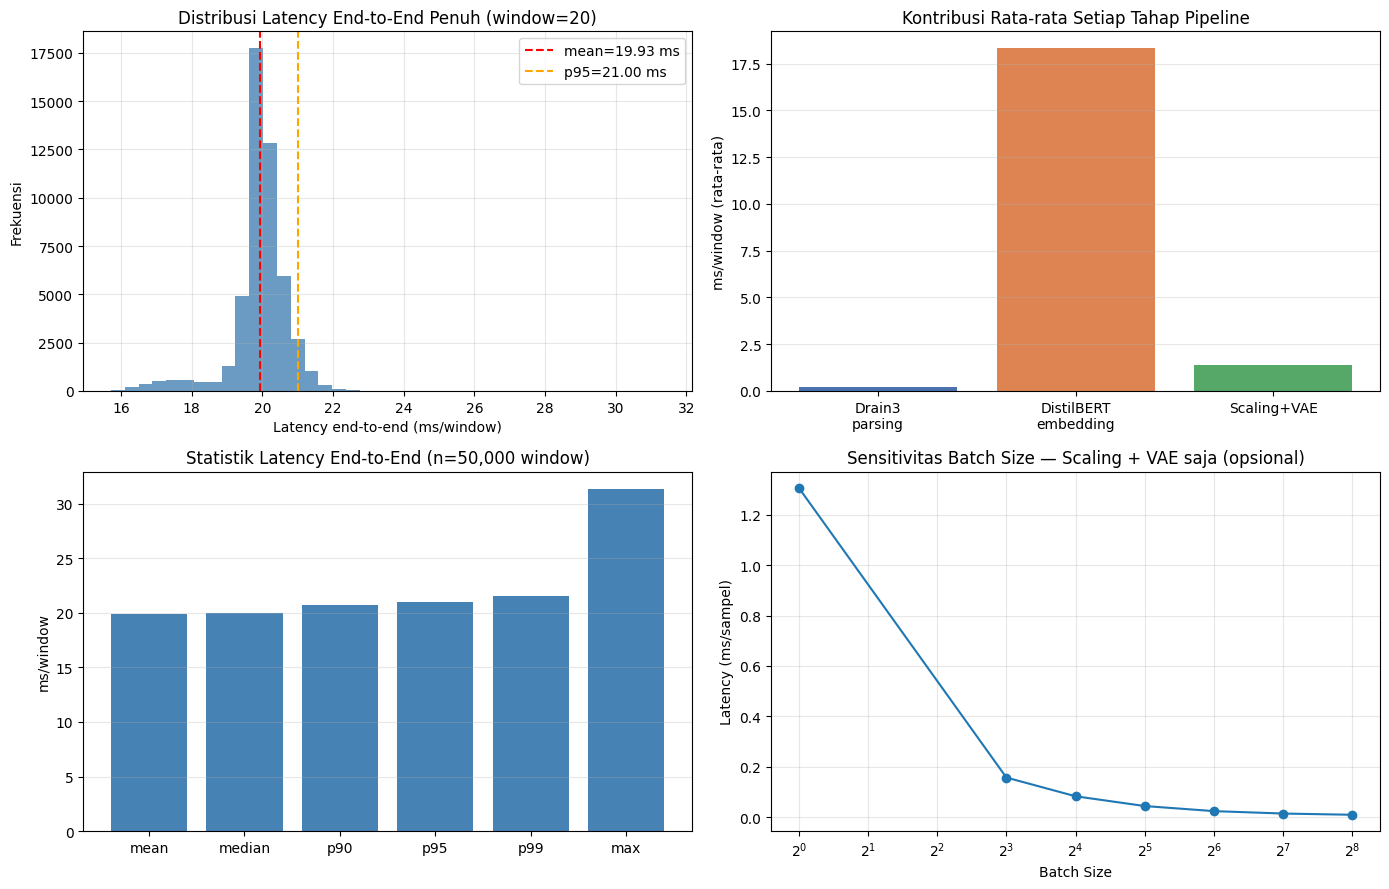

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Distribusi latency end-to-end penuh (per window)
axes[0, 0].hist(e2e_full_df["total_ms"], bins=40, color="steelblue", alpha=0.8)
axes[0, 0].axvline(e2e_summary["mean_ms"], color="red", linestyle="--",
                    label=f"mean={e2e_summary['mean_ms']:.2f} ms")
axes[0, 0].axvline(e2e_summary["p95_ms"], color="orange", linestyle="--",
                    label=f"p95={e2e_summary['p95_ms']:.2f} ms")
axes[0, 0].set_xlabel("Latency end-to-end (ms/window)"); axes[0, 0].set_ylabel("Frekuensi")
axes[0, 0].set_title(f"Distribusi Latency End-to-End Penuh (window={WINDOW_SIZE})")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# Kontribusi tiap tahap terhadap rata-rata latency
stage_labels = ["Drain3\nparsing", "DistilBERT\nembedding", "Scaling+VAE"]
stage_means  = [drain3_summary["mean_ms"], embed_summary["mean_ms"], vae_summary["mean_ms"]]
axes[0, 1].bar(stage_labels, stage_means, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0, 1].set_ylabel("ms/window (rata-rata)")
axes[0, 1].set_title("Kontribusi Rata-rata Setiap Tahap Pipeline")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Statistik persentil end-to-end
pct_labels = ["mean", "median", "p90", "p95", "p99", "max"]
pct_vals = [e2e_summary[f"{p}_ms"] for p in pct_labels]
axes[1, 0].bar(pct_labels, pct_vals, color="steelblue")
axes[1, 0].set_title(f"Statistik Latency End-to-End (n={e2e_summary['n_samples']:,} window)")
axes[1, 0].set_ylabel("ms/window")
axes[1, 0].grid(True, alpha=0.3, axis="y")

# Sensitivitas batch size (Scaling+VAE saja, opsional)
axes[1, 1].plot(vae_stage_df["batch_size"], vae_stage_df["mean_ms_per_sample"], "o-")
axes[1, 1].set_xscale("log", base=2)
axes[1, 1].set_xlabel("Batch Size"); axes[1, 1].set_ylabel("Latency (ms/sampel)")
axes[1, 1].set_title("Sensitivitas Batch Size — Scaling + VAE saja (opsional)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_CONFIG["output_dir"], "inference_latency_benchmark.png"), dpi=150)
plt.show()

## 11. Verdict Kelayakan Produksi

Membandingkan **latency end-to-end penuh** (Drain3 + embedding + VAE, window=20, batch=1 — kondisi
latency terburuk & paling relevan untuk kebutuhan real-time) terhadap target SLA yang dikonfigurasi.

In [13]:
print("=" * 70)
print(" VERDICT KELAYAKAN PRODUKSI — LATENCY INFERENSI END-TO-END")
print("=" * 70)
print(f"\nSkenario end-to-end penuh (Drain3 + Embedding + VAE), window={WINDOW_SIZE}, batch=1:")
print(f"  Latency rata-rata : {e2e_summary['mean_ms']:.2f} ms")
print(f"  Latency p95       : {e2e_summary['p95_ms']:.2f} ms")
print(f"  Latency p99       : {e2e_summary['p99_ms']:.2f} ms")
print(f"  Throughput        : {e2e_summary['throughput_window_per_s']:.1f} window/detik")
print(f"  Estimasi kapasitas: {e2e_summary['throughput_window_per_s']*3600:,.0f} window/jam, "
      f"{e2e_summary['throughput_window_per_s']*86400:,.0f} window/hari")

print(f"\nPenilaian terhadap target SLA (berdasarkan latency p95 end-to-end penuh):")
verdicts = {}
for name, sla_ms in BENCH_CONFIG["sla_targets_ms"].items():
    ok = e2e_summary["p95_ms"] <= sla_ms
    verdicts[name] = bool(ok)
    status = "LAYAK" if ok else "TIDAK LAYAK"
    print(f"  [{status:12s}] {name:28s} (target {sla_ms} ms) -> p95 aktual {e2e_summary['p95_ms']:.2f} ms")

dominant_stage = max(
    [("Drain3 parsing", drain3_summary["mean_ms"]),
     ("DistilBERT embedding", embed_summary["mean_ms"]),
     ("Scaling+VAE", vae_summary["mean_ms"])],
    key=lambda t: t[1],
)[0]

print("\nCatatan:")
print("  - Latency ini mencakup SELURUH pipeline: parsing Drain3 per window, pembentukan")
print("    embedding DistilBERT, hingga perhitungan reconstruction error VAE.")
print(f"  - Tahap dominan penyumbang latency: {dominant_stage} (lihat Bagian 10 untuk rincian).")
print("  - Jika 'TIDAK LAYAK' pada real-time namun 'LAYAK' pada batch/near-real-time,")
print("    pertimbangkan arsitektur micro-batching (kumpulkan beberapa window dalam jendela")
print("    waktu singkat sebelum inferensi) untuk memanfaatkan throughput batch yang lebih")
print("    tinggi (lihat Bagian 9) tanpa mengorbankan responsivitas produksi.")
print("  - Jika DistilBERT adalah kontributor terbesar, pertimbangkan distilasi lebih lanjut,")
print("    kuantisasi (INT8/FP16), ONNX Runtime/TensorRT, atau menjalankan di GPU.")

 VERDICT KELAYAKAN PRODUKSI — LATENCY INFERENSI END-TO-END

Skenario end-to-end penuh (Drain3 + Embedding + VAE), window=20, batch=1:
  Latency rata-rata : 19.93 ms
  Latency p95       : 21.00 ms
  Latency p99       : 21.54 ms
  Throughput        : 50.2 window/detik
  Estimasi kapasitas: 180,603 window/jam, 4,334,470 window/hari

Penilaian terhadap target SLA (berdasarkan latency p95 end-to-end penuh):
  [LAYAK       ] real_time (< 100 ms)         (target 100 ms) -> p95 aktual 21.00 ms
  [LAYAK       ] near_real_time (< 500 ms)    (target 500 ms) -> p95 aktual 21.00 ms
  [LAYAK       ] batch_1s (< 1000 ms)         (target 1000 ms) -> p95 aktual 21.00 ms

Catatan:
  - Latency ini mencakup SELURUH pipeline: parsing Drain3 per window, pembentukan
    embedding DistilBERT, hingga perhitungan reconstruction error VAE.
  - Tahap dominan penyumbang latency: DistilBERT embedding (lihat Bagian 10 untuk rincian).
  - Jika 'TIDAK LAYAK' pada real-time namun 'LAYAK' pada batch/near-real-time,
    

## 12. Simpan Laporan Benchmark

In [14]:
report = {
    "device": str(DEVICE),
    "window_size": WINDOW_SIZE,
    "n_windows_measured": e2e_summary["n_samples"],
    "n_repeat": BENCH_CONFIG["n_repeat"],
    "end_to_end_latency_ms": e2e_summary,
    "stage_breakdown_ms": {
        "drain3_parsing": drain3_summary,
        "distilbert_embedding": embed_summary,
        "scaling_vae": vae_summary,
    },
    "batch_size_sensitivity_scaling_vae": vae_stage_df.to_dict(orient="records"),
    "sla_verdicts": verdicts,
    "sla_targets_ms": BENCH_CONFIG["sla_targets_ms"],
    "threshold_used": THRESHOLD,
}

report_path = os.path.join(BENCH_CONFIG["output_dir"], "inference_latency_report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"Laporan benchmark disimpan di: {report_path}")

Laporan benchmark disimpan di: /kaggle/working/inference_latency_report.json
